In [33]:
import pandas as pd
import matplotlib.pyplot as plt
print("Imported libraries sucessfully....")

Imported libraries sucessfully....


In [34]:
#getting the raw data sheet for gold
from openpyxl import load_workbook as loadGold

gold = loadGold("../raw data/gold.xlsx")
sheet1 = gold.active

print("Successfully Loaded file: ", sheet1.title)

Successfully Loaded file:  Report 1


In [35]:
#checkpoint
print(sheet1["B2"].value)

Monthly Average Price of Gold and Silver in Domestic and Foreign Markets


In [36]:
#getting raw data sheet for all cpi
from openpyxl import load_workbook as getbasket

basket = getbasket("../raw data/cpi.xlsx")
sheet2 = basket.active

print("Successfully loaded file: ", sheet2.title)

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Successfully loaded file:  CPI - 2012=100 (All India) (1)


In [37]:
#checkpoint
print(sheet2["B2"].value)

CPI - Rural, Urban, Combined (All India)


In [38]:
#counting total data points
#from January 2013 till September 2025
syear=2013
smonth=1
eyear=2025
emonth=9

#formula
c = (eyear-syear)*12 + emonth - smonth + 1
print(c)

#expected upperbound
e = c*6 #took 6 coz basket will have 6 components
print(e)

153
918


In [39]:
#extracting gold values
gvalues = []
count = 0
for row in sheet1.iter_rows(min_row=8, values_only=True):
    val = row[2]
    name = row[1]
    if val is not None and name != "Average" and count < c:
        gvalues.append(val)
        gvalues[count] = round(gvalues[count], 2)
        count += 1
#for g in gvalues:
#    print(g)

In [40]:
#extracting index categorically
general = []
food = []
house = []
fuel = []
transport = []
misc = []

count = 0

for row in sheet2.iter_rows(min_row=8, values_only=True):
    check = row[3]
    commodity = row[2]
    val = row[8]
    if check == "Final" and count < e:
        if commodity == "A) General Index":
            general.append(val)
            count += 1
        elif commodity == "A.1) Food and beverages":
            food.append(val)
            count += 1
        elif commodity == "A.4) Housing":
            house.append(val)
            count += 1
        elif commodity == "A.5) Fuel and light":
            fuel.append(val)
            count += 1
        elif commodity == "A.6) Miscellaneous":
            misc.append(val)
            count += 1
        elif commodity == "A.6.3) Transport and communication":
            transport.append(val)
            count += 1

##checking type "c" when needed :)
#for i in range(10):
#    print(i, "1.", general[i], "  2.", food[i], "  3.", house[i], "  4.", fuel[i], "  5.", misc[i], "  6.", transport[i])


In [41]:
#getting right timeline
dates = pd.date_range(start='2025-09-01', end='2013-01-01', freq='-1MS')
print(dates)

DatetimeIndex(['2025-09-01', '2025-08-01', '2025-07-01', '2025-06-01',
               '2025-05-01', '2025-04-01', '2025-03-01', '2025-02-01',
               '2025-01-01', '2024-12-01',
               ...
               '2013-10-01', '2013-09-01', '2013-08-01', '2013-07-01',
               '2013-06-01', '2013-05-01', '2013-04-01', '2013-03-01',
               '2013-02-01', '2013-01-01'],
              dtype='datetime64[ns]', length=153, freq='-1MS')


In [42]:
#making the gold data frame
goldata = pd.DataFrame({
    'Dates': dates,
    'Gold Price': gvalues
})

#storing gold data
goldata.to_csv('../clean data/goldata.csv')
goldata.to_excel('../clean data/goldata.xlsx')

#checkpoint
print(goldata)

         Dates  Gold Price
0   2025-09-01   109590.91
1   2025-08-01    99696.47
2   2025-07-01    97581.22
3   2025-06-01    97175.81
4   2025-05-01    94589.81
..         ...         ...
148 2013-05-01    26768.65
149 2013-04-01    27742.60
150 2013-03-01    29513.75
151 2013-02-01    29963.48
152 2013-01-01    30520.19

[153 rows x 2 columns]


In [43]:
#making the dataframe for cpi
indexdata = pd.DataFrame({
    'Dates': dates,
    'General': general,
    'Food & Beverages': food,
    'Housing': house,
    'Fuel & Light': fuel,
    'Transport & Communication': transport,
    'Miscellaneous': misc
})

#storing cpi data
indexdata.to_csv('../clean data/indexdata.csv')
indexdata.to_excel('../clean data/indexdata.xlsx')


#checkpoint
print(indexdata)

         Dates  General  Food & Beverages  Housing  Fuel & Light  \
0   2025-09-01    197.0             202.0    186.4         180.4   
1   2025-08-01    197.0             202.8    186.7         180.8   
2   2025-07-01    196.1             201.6    185.7         180.7   
3   2025-06-01    194.2             198.1    184.8         180.8   
4   2025-05-01    193.0             196.1    185.8         181.1   
..         ...      ...               ...      ...           ...   
148 2013-05-01    106.9             109.2    100.5         107.4   
149 2013-04-01    106.1             107.7    100.5         106.5   
150 2013-03-01    105.5             106.9    100.4         106.1   
151 2013-02-01    105.3             106.6    100.4         106.0   
152 2013-01-01    104.6             105.6    100.3         105.5   

     Transport & Communication  Miscellaneous  
0                        173.6          194.9  
1                        173.7          193.6  
2                        173.5         

In [44]:
#final outputttt
data = pd.merge(goldata, indexdata, on='Dates', how='inner')

#save the data
data.to_csv('../clean data/clean.csv')
data.to_excel('../clean data/clean.xlsx')

#doneeeeee
print(data)

         Dates  Gold Price  General  Food & Beverages  Housing  Fuel & Light  \
0   2025-09-01   109590.91    197.0             202.0    186.4         180.4   
1   2025-08-01    99696.47    197.0             202.8    186.7         180.8   
2   2025-07-01    97581.22    196.1             201.6    185.7         180.7   
3   2025-06-01    97175.81    194.2             198.1    184.8         180.8   
4   2025-05-01    94589.81    193.0             196.1    185.8         181.1   
..         ...         ...      ...               ...      ...           ...   
148 2013-05-01    26768.65    106.9             109.2    100.5         107.4   
149 2013-04-01    27742.60    106.1             107.7    100.5         106.5   
150 2013-03-01    29513.75    105.5             106.9    100.4         106.1   
151 2013-02-01    29963.48    105.3             106.6    100.4         106.0   
152 2013-01-01    30520.19    104.6             105.6    100.3         105.5   

     Transport & Communication  Miscell

In [45]:
#rebased df make exist
rebase = pd.DataFrame({
    'Dates': dates,
    'Gold' : None,
    'General' : None,
    'Food & Beverages' : None,
    'Housing': None,
    'Fuel & Light': None,
    'Transport & Communication': None,
    'Miscellaneous': None
})

#checkinggggg
print(rebase)
    

         Dates  Gold General Food & Beverages Housing Fuel & Light  \
0   2025-09-01  None    None             None    None         None   
1   2025-08-01  None    None             None    None         None   
2   2025-07-01  None    None             None    None         None   
3   2025-06-01  None    None             None    None         None   
4   2025-05-01  None    None             None    None         None   
..         ...   ...     ...              ...     ...          ...   
148 2013-05-01  None    None             None    None         None   
149 2013-04-01  None    None             None    None         None   
150 2013-03-01  None    None             None    None         None   
151 2013-02-01  None    None             None    None         None   
152 2013-01-01  None    None             None    None         None   

    Transport & Communication Miscellaneous  
0                        None          None  
1                        None          None  
2                    

In [47]:
#everything starts with a 100 lmao
length = len(rebase)

#set base 100 in cols
rebase.loc[152, "Gold"] = 100
rebase.loc[152, "General"] = 100
rebase.loc[152, "Food & Beverages"] = 100
rebase.loc[152, "Housing"] = 100
rebase.loc[152, "Fuel & Light"] = 100
rebase.loc[152, "Transport & Communication"] = 100
rebase.loc[152, "Miscellaneous"] = 100

#now the imp chunk
for i in range(length):
    for j in range (7):
        #get it
        val = data.iloc[i, j+1]
        base = data.iloc[-1, j+1]
        #coreeee
        valnew = (val/base)*100
        rebase.iloc[i, j+1] = valnew

        j+=1
    i+=1

#technicalities :)
rev_rebase = rebase.iloc[::-1]


print(rev_rebase)
    
    


         Dates        Gold     General Food & Beverages     Housing  \
152 2013-01-01       100.0       100.0            100.0       100.0   
151 2013-02-01   98.175929  100.669216        100.94697  100.099701   
150 2013-03-01    96.70238  100.860421       101.231061  100.099701   
149 2013-04-01   90.899172  101.434034       101.988636  100.199402   
148 2013-05-01   87.708006  102.198853       103.409091  100.199402   
..         ...         ...         ...              ...         ...   
4   2025-05-01  309.925364  184.512428       185.700758  185.244267   
3   2025-06-01  318.398444  185.659656       187.594697  184.247258   
2   2025-07-01  319.726778  187.476099       190.909091  185.144566   
1   2025-08-01  326.657436   188.33652       192.045455  186.141575   
0   2025-09-01  359.076762   188.33652       191.287879  185.842473   

    Fuel & Light Transport & Communication Miscellaneous  
152        100.0                     100.0         100.0  
151   100.473934             

In [32]:
#making filessss

rebase.to_csv('../clean data/rebased.csv')
rebase.to_excel('../clean data/rebased.xlsx')


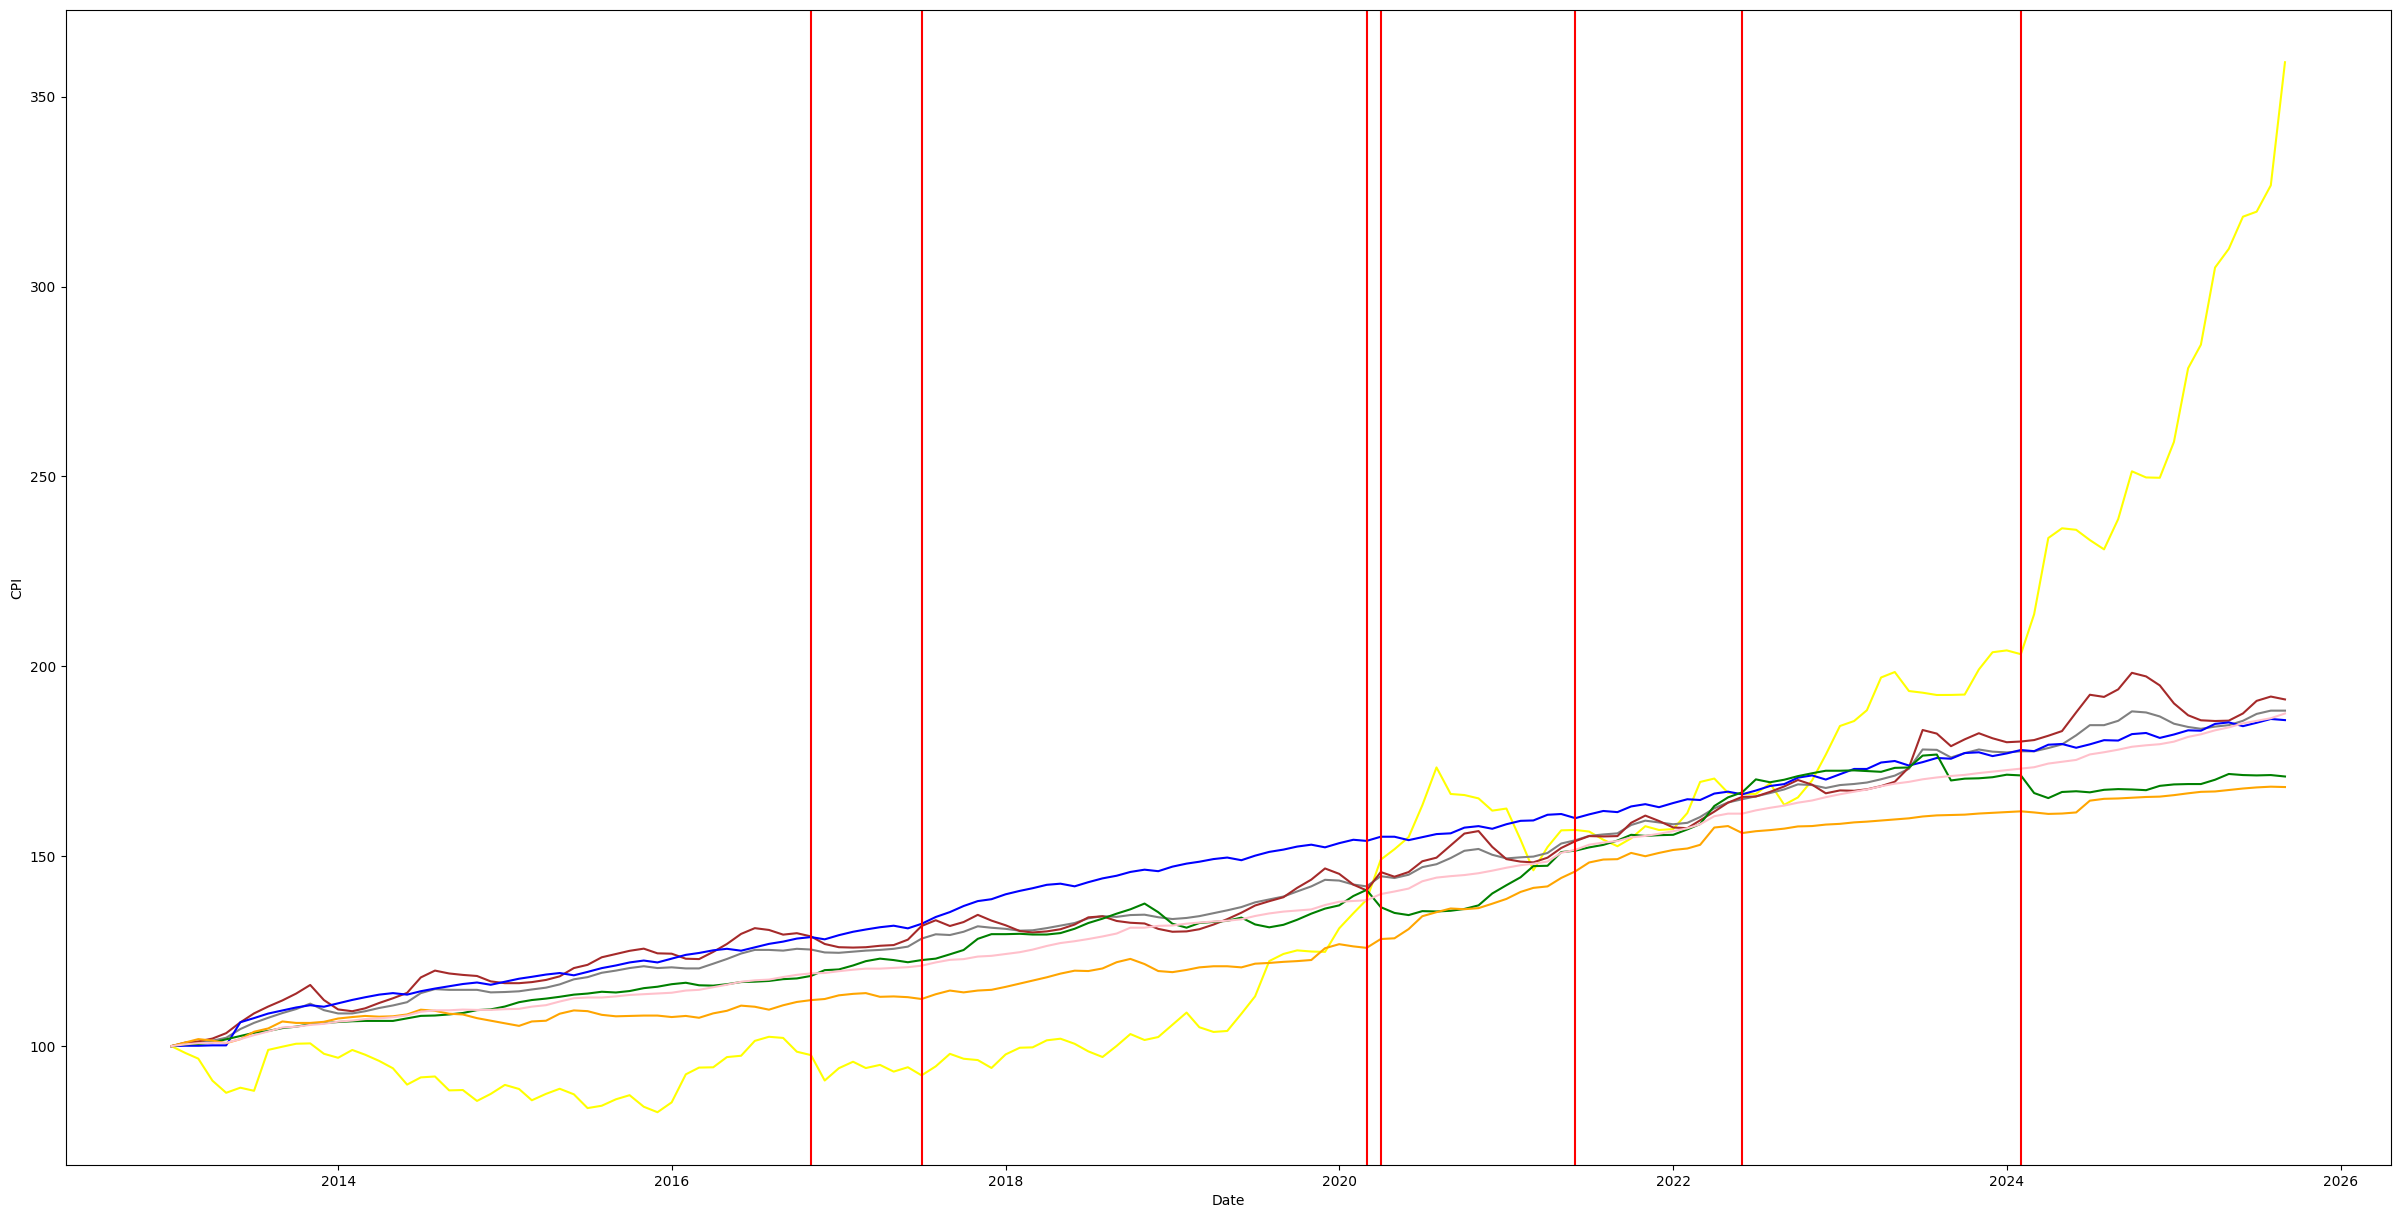

In [62]:
#now the one with the graph
plt.figure(figsize=(30,15))

plt.plot(rev_rebase["Dates"], rev_rebase["Gold"], color = 'yellow', label = "Gold")
plt.plot(rev_rebase["Dates"], rev_rebase["General"], color = 'grey', label = "General")
plt.plot(rev_rebase["Dates"], rev_rebase["Food & Beverages"], color = 'brown', label = "Food & Beverages")
plt.plot(rev_rebase["Dates"], rev_rebase["Housing"], color = 'blue', label = "Housing")
plt.plot(rev_rebase["Dates"], rev_rebase["Fuel & Light"], color = 'green', label = "Fuel & Light")
plt.plot(rev_rebase["Dates"], rev_rebase["Transport & Communication"], color = 'orange', label = "Transport & Communication")
plt.plot(rev_rebase["Dates"], rev_rebase["Miscellaneous"], color = 'pink', label = "Miscellaneous")

plt.xlabel("Date")
plt.ylabel("CPI")

#adding main stuff
incidents = ["2016-11-01", "2017-07-01", "2020-03-01", "2020-04-01", "2021-06-01", "2022-06-01", "2024-02-01"]
incidents = pd.to_datetime(incidents)


for date in incidents:
    plt.axvline(x=date, color='red')


In [60]:
#ughhh will look into this tmrw atp idek what i am doing